In [2]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

# Set seed for reproducibility
np.random.seed(42)
random.seed(42)

# Number of borrowers
n_borrowers = 2000

# Generate dates
start_date = datetime(2020, 1, 1)
end_date = datetime(2023, 12, 31)
time_between_dates = end_date - start_date
days_between_dates = time_between_dates.days
random_number_of_days = np.random.randint(0, days_between_dates, size=n_borrowers)
loan_dates = [start_date + timedelta(days=int(x)) for x in random_number_of_days]

# Generate data
data = {
    'BorrowerID': range(1, n_borrowers + 1),
    'LoanDate': loan_dates,
    'LoanAmount': np.random.randint(1000, 50000, size=n_borrowers),
    'InterestRate': np.random.uniform(0.05, 0.25, size=n_borrowers),
    'LoanTermMonths': np.random.choice([12, 24, 36, 48, 60], size=n_borrowers),
    'CreditScore': np.random.randint(500, 850, size=n_borrowers),
    'AnnualIncome': np.random.randint(20000, 200000, size=n_borrowers),
    'DebtToIncomeRatio': np.random.uniform(0.1, 0.6, size=n_borrowers),
    'EmploymentLengthYears': np.random.randint(0, 20, size=n_borrowers),
    'HomeOwnership': np.random.choice(['Rent', 'Mortgage', 'Own'], size=n_borrowers),
    'Purpose': np.random.choice(['Debt Consolidation', 'Home Improvement', 'Credit Card Refinancing', 'Other', 'Business'], size=n_borrowers),
    'MonthlyPayment': np.random.randint(100, 2000, size=n_borrowers),
    'OpenAccounts': np.random.randint(1, 15, size=n_borrowers),
    'TotalAccounts': np.random.randint(2, 30, size=n_borrowers),
    'MonthsSinceLastDelinquency': np.random.choice([None] + list(range(1, 60)), size=n_borrowers), #null values are important
    'RevolvingUtilization': np.random.uniform(0, 1, size=n_borrowers),
    'HasBankruptcies': np.random.choice([0, 1], p=[0.95, 0.05], size=n_borrowers),
    'HasTaxLiens': np.random.choice([0, 1], p=[0.98, 0.02], size=n_borrowers),
    'State': np.random.choice(['CA', 'NY', 'TX', 'FL', 'IL', 'PA', 'OH', 'GA', 'NC', 'MI'], size=n_borrowers),
    'Age': np.random.randint(22, 70, size=n_borrowers),
    'EducationLevel': np.random.choice(['High School', 'Associate\'s', 'Bachelor\'s', 'Master\'s', 'PhD'], size=n_borrowers),
    'MaritalStatus': np.random.choice(['Single', 'Married', 'Divorced', 'Widowed'], size=n_borrowers),
    'NumberOfDependents': np.random.randint(0, 5, size=n_borrowers),
    'TimeAtCurrentAddressMonths': np.random.randint(1, 240, size=n_borrowers),
    'Defaulted': np.random.choice([0, 1], p=[0.9, 0.1], size=n_borrowers) #10% default rate
}

df = pd.DataFrame(data)

# Convert LoanDate to datetime
df['LoanDate'] = pd.to_datetime(df['LoanDate'])

# Replace None with NaN for MonthsSinceLastDelinquency
df['MonthsSinceLastDelinquency'] = df['MonthsSinceLastDelinquency'].astype(float).replace(np.nan, np.nan)

# Display the first few rows
print(df.head())

# Save to CSV
import sys
from pathlib import Path
_repo = Path.cwd().resolve()
for _ in range(12):
    if (_repo / "utils" / "data_paths.py").exists():
        sys.path.insert(0, str(_repo))
        break
    if _repo.parent == _repo:
        raise FileNotFoundError("Run from ml-notebook root")
    _repo = _repo.parent
from utils.data_paths import data_dir
df.to_csv(data_dir() / "p2p_lending_data.csv", index=False)


   BorrowerID   LoanDate  LoanAmount  InterestRate  LoanTermMonths  \
0           1 2023-01-31       37142      0.108229              12   
1           2 2023-12-30       40198      0.091419              60   
2           3 2022-05-10       45738      0.080466              24   
3           4 2023-07-18       34397      0.229891              12   
4           5 2023-02-04       17653      0.192027              24   

   CreditScore  AnnualIncome  DebtToIncomeRatio  EmploymentLengthYears  \
0          751        187207           0.521589                      3   
1          689         93631           0.340490                      4   
2          651         57909           0.203012                      7   
3          801         89487           0.514222                      0   
4          777        172540           0.368886                      5   

  HomeOwnership  ... RevolvingUtilization  HasBankruptcies  HasTaxLiens  \
0           Own  ...             0.399215                0 

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

import sys
from pathlib import Path
_repo = Path.cwd().resolve()
for _ in range(12):
    if (_repo / "utils" / "data_paths.py").exists():
        sys.path.insert(0, str(_repo))
        break
    if _repo.parent == _repo:
        raise FileNotFoundError("Could not find utils/data_paths.py; run Jupyter from ml-notebook repo.")
    _repo = _repo.parent
from utils.data_paths import data_dir
DATA = data_dir()
df = pd.read_csv(DATA / "p2p_lending_data.csv")

# Preprocessing
# Convert categorical variables to numerical using one-hot encoding
categorical_cols = ['HomeOwnership', 'Purpose', 'State', 'EducationLevel', 'MaritalStatus']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Handle missing values (impute with median for simplicity)
df['MonthsSinceLastDelinquency'] = df['MonthsSinceLastDelinquency'].fillna(df['MonthsSinceLastDelinquency'].median())

# Drop BorrowerID and LoanDate (for now)
df = df.drop(['BorrowerID', 'LoanDate'], axis=1)

,LoanAmount,InterestRate,LoanTermMonths,CreditScore,AnnualIncome,DebtToIncomeRatio,EmploymentLengthYears,MonthlyPayment,OpenAccounts,TotalAccounts,...,State_OH,State_PA,State_TX,EducationLevel_Bachelor's,EducationLevel_High School,EducationLevel_Master's,EducationLevel_PhD,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed
0,37142,0.108229,12,751,187207,0.521589,3,1115,11,18,...,False,False,False,False,False,False,False,False,False,False
1,40198,0.091419,60,689,93631,0.340490,4,435,7,21,...,False,True,False,False,True,False,False,True,False,False
2,45738,0.080466,24,651,57909,0.203012,7,765,7,23,...,False,False,False,False,False,False,False,False,True,False
3,34397,0.229891,12,801,89487,0.514222,0,1094,5,12,...,False,False,False,False,True,False,False,False,True,False
4,17653,0.192027,24,777,172540,0.368886,5,180,3,13,...,False,False,True,False,True,False,False,False,False,False


In [5]:
pd.set_option('display.max_columns', None)
df.head()

,LoanAmount,InterestRate,LoanTermMonths,CreditScore,AnnualIncome,DebtToIncomeRatio,EmploymentLengthYears,MonthlyPayment,OpenAccounts,TotalAccounts,MonthsSinceLastDelinquency,RevolvingUtilization,HasBankruptcies,HasTaxLiens,Age,NumberOfDependents,TimeAtCurrentAddressMonths,Defaulted,HomeOwnership_Own,HomeOwnership_Rent,Purpose_Credit Card Refinancing,Purpose_Debt Consolidation,Purpose_Home Improvement,Purpose_Other,State_FL,State_GA,State_IL,State_MI,State_NC,State_NY,State_OH,State_PA,State_TX,EducationLevel_Bachelor's,EducationLevel_High School,EducationLevel_Master's,EducationLevel_PhD,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed
0,37142,0.108229,12,751,187207,0.521589,3,1115,11,18,10.0,0.399215,0,0,26,4,52,0,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,40198,0.091419,60,689,93631,0.340490,4,435,7,21,16.0,0.653056,0,0,29,4,67,0,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False
2,45738,0.080466,24,651,57909,0.203012,7,765,7,23,32.0,0.185615,0,0,42,1,85,0,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False
3,34397,0.229891,12,801,89487,0.514222,0,1094,5,12,10.0,0.823917,0,0,68,0,75,0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False
4,17653,0.192027,24,777,172540,0.368886,5,180,3,13,38.0,0.180193,0,0,26,1,136,0,False,True,True,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False


In [6]:
# Separate features and target
X = df.drop('Defaulted', axis=1)
y = df['Defaulted']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# Logistic Regression Model
logistic_model = LogisticRegression(solver='liblinear', random_state=42)
logistic_model.fit(X_train, y_train)
logistic_predictions = logistic_model.predict(X_test)
logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Results:")
print(classification_report(y_test, logistic_predictions))
print("AUC-ROC:", roc_auc_score(y_test, logistic_probabilities))

Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93       351
           1       0.00      0.00      0.00        49

    accuracy                           0.88       400
   macro avg       0.44      0.50      0.47       400
weighted avg       0.77      0.88      0.82       400

AUC-ROC: 0.4946217803360661


/Users/robbieardison/anaconda3/envs/tf-pro/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/robbieardison/anaconda3/envs/tf-pro/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/robbieardison/anaconda3/envs/tf-pro/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [8]:
# LightGBM Model
lgbm_model = lgb.LGBMClassifier(random_state=42)
lgbm_model.fit(X_train, y_train)
lgbm_predictions = lgbm_model.predict(X_test)
lgbm_probabilities = lgbm_model.predict_proba(X_test)[:, 1]

print("\nLightGBM Results:")
print(classification_report(y_test, lgbm_predictions))
print("AUC-ROC:", roc_auc_score(y_test, lgbm_probabilities))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 154, number of negative: 1446
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000753 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2228
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.096250 -> initscore=-2.239604
[LightGBM] [Info] Start training from score -2.239604

LightGBM Results:
              precision    recall  f1-score   support

           0       0.88      1.00      0.93       351
           1       0.00      0.00      0.00        49

    accuracy                           0.88       400
   macro avg       0.44      0.50      0.47       400
weighted avg       0.77      0.88      0.82       400

AUC-ROC: 0.533693819

/Users/robbieardison/anaconda3/envs/tf-pro/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/robbieardison/anaconda3/envs/tf-pro/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/robbieardison/anaconda3/envs/tf-pro/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

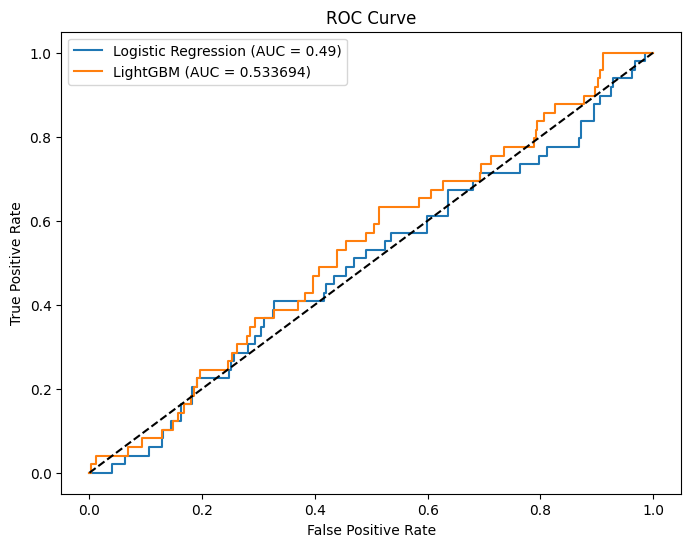


LightGBM Feature Importance:
                       Feature  Importance
1                 InterestRate         259
5            DebtToIncomeRatio         253
16  TimeAtCurrentAddressMonths         236
0                   LoanAmount         230
7               MonthlyPayment         224
11        RevolvingUtilization         224
10  MonthsSinceLastDelinquency         218
4                 AnnualIncome         217
3                  CreditScore         216
14                         Age         147


In [9]:
# ROC Curve Visualization
fpr_logistic, tpr_logistic, _ = roc_curve(y_test, logistic_probabilities)
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, lgbm_probabilities)

plt.figure(figsize=(8, 6))
plt.plot(fpr_logistic, tpr_logistic, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, logistic_probabilities):.2f})')
plt.plot(fpr_lgbm, tpr_lgbm, label=f'LightGBM (AUC = {roc_auc_score(y_test, lgbm_probabilities):2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

#Feature Importance (LightGBM)
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': lgbm_model.feature_importances_})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print("\nLightGBM Feature Importance:")
print(feature_importance.head(10)) #Show only top 10.

In [13]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Now use X_train_resampled and y_train_resampled to train your model
#Example with logistic regression.
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(solver='liblinear', random_state=42)
model.fit(X_train_resampled, y_train_resampled)
logistic_predictions = model.predict(X_test)
logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Results:")
print(classification_report(y_test, logistic_predictions))
print("AUC-ROC:", roc_auc_score(y_test, logistic_probabilities))


#Example with LightGBM and class weights.
import lightgbm as lgb
model_lgbm = lgb.LGBMClassifier(random_state=42, scale_pos_weight=(sum(y_train == 0) / sum(y_train == 1)))
model_lgbm.fit(X_train, y_train)
lgbm_predictions = model_lgbm.predict(X_test)
lgbm_probabilities = model_lgbm.predict_proba(X_test)[:, 1]

print("\nLightGBM Results:")
print(classification_report(y_test, lgbm_predictions))
print("AUC-ROC:", roc_auc_score(y_test, lgbm_probabilities))

Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.87      0.89      0.88       351
           1       0.07      0.06      0.07        49

    accuracy                           0.79       400
   macro avg       0.47      0.48      0.48       400
weighted avg       0.77      0.79      0.78       400

AUC-ROC: 0.4946217803360661
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 154, number of negative: 1446
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003544 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2228
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.096250 -> initscore=-2.239604
[LightGBM] [Info] Start training fro